# Lab 4.2 — Text Representation & Document Classification
**Module 4: Applied Natural Language Processing**

In this lab you will:
- Convert preprocessed text into numeric vectors using **Bag-of-Words** and **TF-IDF**
- Build intuition for **word embeddings** using Gensim Word2Vec on our corpus
- Train and compare three classifiers: **Naive Bayes**, **Logistic Regression**, **SVM**
- Evaluate with accuracy, F1-score, and confusion matrices
- Understand *why* TF-IDF outperforms raw counts for unbalanced term frequencies

> **Instructor Note:** This lab is the bridge from preprocessing to production. The representation scheme is often *more important* than the classifier choice — a great TF-IDF with a simple Logistic Regression almost always beats a complex deep network on a bag-of-tokens vectorised input.
\

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name | Notes |
|---------|-------------|-------|
| scikit-learn | `scikit-learn` | Provides `CountVectorizer`, `TfidfVectorizer`, `LinearSVC`, classifiers |
| pandas | `pandas` | |
| numpy | `numpy` | |
| matplotlib | `matplotlib` | |
| gensim | `gensim` | Word2Vec embeddings — may take a moment to install |
| nltk | `nltk` | Required if running the inline fallback (Lab 4.1 CSV not found) |

**Install all at once:**
```bash
pip install scikit-learn pandas numpy matplotlib gensim nltk
```

---

### ⚠️ Common Errors & Fixes

**`ModuleNotFoundError: No module named '...'`**
> Package is missing from the active Python environment.
> Fix: Run the pip install command above in a terminal, then **restart the kernel**.

**`CalledProcessError` — `--break-system-packages` / exit status 2**
> You are using a virtual environment (e.g. `myenv`) where that flag is not supported, or your pip version is old.
> Fix: Open a terminal, activate your venv (`source myenv/bin/activate`), then run `pip install <package>` without that flag.

**`FileNotFoundError: tickets_preprocessed.csv`**
> Lab 4.1 has not been run yet — the preprocessed dataset doesn't exist.
> Fix: Run **Lab 4.1** first, or let the inline fallback in Section 1 regenerate it automatically.

**`Failed building wheel for gensim` / C extension errors**
> Gensim needs a C compiler. Most common on fresh macOS without Xcode tools.
> Fix: Run `xcode-select --install` in a terminal, then retry. Alternatively switch to Python 3.11 or 3.13 where pre-built wheels exist.

**`Failed building wheel for <package>` / unsupported Python version**
> Most common on Python 3.14 where binary wheels aren't yet published.
> Fix: Switch the kernel to **Python 3.13**. Click the kernel name in the VS Code top-right corner → *Select Another Kernel* → *Python 3.13*. Then re-run.

**Packages install with no error but `ModuleNotFoundError` still appears**
> You installed into a different Python than the one the notebook is using.
> Fix: Check the kernel shown in the top-right of VS Code. Open a terminal, activate that environment, and install packages there.

**`PermissionError` or `[Errno 13]` when installing**
> Trying to install into a read-only system Python.
> Fix: Use a virtual environment — `python -m venv myenv && source myenv/bin/activate` — then install.

In [1]:
import subprocess, sys

required = {
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'gensim': 'gensim',
}
for pkg, inst in required.items():
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', inst, '--quiet', '--break-system-packages'])

import warnings
warnings.filterwarnings('ignore')
print('All packages ready ✅')

  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [785 lines of output]
      /private/var/folders/nr/zr3cbb4j2dz42fkzm9zw80080000gp/T/pip-build-env-4wt3isq_/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/nr/zr3cbb4j2dz42fkzm9zw80080000gp/T/pip-build-env-4wt3isq_/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build/lib.macosx-26.0-arm64-cpython-314/gensim
      copying gensim/interfaces.py -> build/lib.macosx-26.0-arm64-cpython-314/gensim
      copying gensim/downloader.py -> build/lib.macosx-26.0-arm64-cpython-314/gensim
      copying gensim/matutils.py -> build/lib.macosx-26.0

CalledProcessError: Command '['/opt/homebrew/opt/python@3.14/bin/python3.14', '-m', 'pip', 'install', 'gensim', '--quiet', '--break-system-packages']' returned non-zero exit status 1.

## 1. Load Preprocessed Tickets from Lab 4.1

> **Instructor Note:** If Lab 4.1 hasn't been run yet, we recreate the preprocessed dataset inline as a fallback. This is the same pattern used in Module 3 — labs are executable in isolation.

In [ ]:
import os
import pandas as pd
import numpy as np

CSV_PATH = 'tickets_preprocessed.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f'✅ Loaded {len(df)} tickets from {CSV_PATH}')
else:
    # Inline fallback — runs Lab 4.1 preprocessing automatically
    import nltk, re
    for r in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
        nltk.download(r, quiet=True)
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    ALL_STOPS = set(stopwords.words('english')) | {
        'nutanix', 'node', 'cluster', 'vm', 'vms', 'issue', 'error',
        'please', 'hi', 'hello', 'ticket', 'problem', 'thank', 'thanks'
    }
    lem = WordNetLemmatizer()

    def preprocess(text, min_len=3):
        tokens = word_tokenize(text.lower())
        tokens = [t for t in tokens if re.match(r'^[a-z]+$', t)]
        tokens = [t for t in tokens if t not in ALL_STOPS]
        tokens = [lem.lemmatize(t, pos='v') for t in tokens]
        return ' '.join([t for t in tokens if len(t) >= min_len])

    raw_tickets = [
        {'text': 'Stargate process crashed on CVM node-3 after disk sda3 threw multiple IO errors during peak hours', 'category': 'storage'},
        {'text': 'NFS datastore becomes inaccessible intermittently, getting EXT4-fs errors in kernel log', 'category': 'storage'},
        {'text': 'Disk tier migration from SSD to HDD is stuck at 45% for more than 6 hours', 'category': 'storage'},
        {'text': 'Data path throughput dropped by 60% after replacing failed SSD on node-2', 'category': 'storage'},
        {'text': 'Storage pool utilization reached 92%, curator scan failing to reclaim space', 'category': 'storage'},
        {'text': 'Stargate OOM killed after memory pressure during large sequential writes to HDD tier', 'category': 'storage'},
        {'text': 'NDFS mount failed on AHV host, unable to access any VMs on that datastore', 'category': 'storage'},
        {'text': 'Disk bad sectors detected on SATA drive in node-1, Stargate marked drive as unhealthy', 'category': 'storage'},
        {'text': 'Data locality policy not being enforced after cluster expansion with two new nodes added', 'category': 'storage'},
        {'text': 'Read performance degraded after rolling upgrade to AOS 6.5, IOPS dropped significantly', 'category': 'storage'},
        {'text': '10GbE NIC on node-4 shows frequent link flaps causing packet loss for running VMs', 'category': 'network'},
        {'text': 'AHV host cannot reach default gateway after OVS bridge configuration change', 'category': 'network'},
        {'text': 'LACP bond interface went down on node-2 after upstream switch firmware update', 'category': 'network'},
        {'text': 'VM network connectivity intermittently lost, OVS flow table shows duplicate MAC entries', 'category': 'network'},
        {'text': 'BGP session dropping between cluster and ToR switch causing VIP failover events', 'category': 'network'},
        {'text': 'Jumbo frames not accepted on storage network, MTU mismatch causing Stargate packet drops', 'category': 'network'},
        {'text': 'Ping latency from CVM to AHV host spiking to 50ms, expected sub-millisecond on local interface', 'category': 'network'},
        {'text': 'IPAM address pool exhausted on VM network, new VM deployments failing with IP allocation error', 'category': 'network'},
        {'text': 'Flow network policy blocking legitimate VM to VM traffic on the same subnet', 'category': 'network'},
        {'text': 'CVM external IP unreachable from management network after VLAN reconfiguration last night', 'category': 'network'},
        {'text': 'VM fails to power on, not enough memory available on AHV host after adding four new VMs', 'category': 'compute'},
        {'text': 'AHV live migration fails with dirty page transfer timeout after 300 seconds elapsed', 'category': 'compute'},
        {'text': 'CVM memory usage at 98%, acropolis service consuming unexpectedly high heap memory', 'category': 'compute'},
        {'text': 'Guest VM showing blue screen after vCPU hot-add operation on Windows Server 2019', 'category': 'compute'},
        {'text': 'CPU ready time spiking above 20% on overcommitted host, virtual machine performance degraded', 'category': 'compute'},
        {'text': 'AHV host entered maintenance mode unexpectedly during workload, VMs migrated to other nodes', 'category': 'compute'},
        {'text': 'VM clone operation failing at 30% with qcow2 image corruption error in acropolis log', 'category': 'compute'},
        {'text': 'NUMA topology not respected for latency sensitive database VM after node restart', 'category': 'compute'},
        {'text': 'Balloon driver inflating inside guest causing application out of memory inside Windows VM', 'category': 'compute'},
        {'text': 'VirtIO network driver crash inside guest causing virtual machine to become unresponsive', 'category': 'compute'},
        {'text': 'Prism Central UI shows blank page after login, browser console shows 502 bad gateway error', 'category': 'prism'},
        {'text': 'REST API v3 /vms endpoint returning 504 timeout for requests listing more than 100 VMs', 'category': 'prism'},
        {'text': 'Prism Element cluster health shows warning state but no specific alert details are visible', 'category': 'prism'},
        {'text': 'Alert email notifications stopped working after SMTP server IP address change in Prism settings', 'category': 'prism'},
        {'text': 'Prism Central data collection job is stuck, analytics graphs show stale data from 3 hours ago', 'category': 'prism'},
        {'text': 'SSO login redirecting to wrong Prism Central instance after DNS change in the environment', 'category': 'prism'},
        {'text': 'REST API rate limiting triggered at 100 requests per minute affecting automation scripts', 'category': 'prism'},
        {'text': 'Prism Central upgrade from 2022 to 2023 failed at post upgrade health check step', 'category': 'prism'},
        {'text': 'Category management API returning 403 forbidden for non-admin user despite correct RBAC policy', 'category': 'prism'},
        {'text': 'Capacity planning chart showing incorrect storage runway calculation for SSD tier', 'category': 'prism'},
        {'text': 'Cerebro async replication failing between primary and recovery sites, lag exceeded 4 hours', 'category': 'replication'},
        {'text': 'Synchronous replication partner site unreachable, protection domain status showing error state', 'category': 'replication'},
        {'text': 'Snapshot replication schedule not triggering at configured 15 minute interval', 'category': 'replication'},
        {'text': 'Metro availability failover test failed, witness VM not responding to heartbeat probe', 'category': 'replication'},
        {'text': 'DR runbook automation failed to power on virtual machines in recovery site after planned failover', 'category': 'replication'},
        {'text': 'Cerebro replication bandwidth throttled to 10Mbps, expected 1Gbps during batch replication window', 'category': 'replication'},
        {'text': 'Consistency group snapshot incomplete, some VMs excluded because quiescing operation timed out', 'category': 'replication'},
        {'text': 'Replication job consuming 100% of WAN link causing production latency increase during business hours', 'category': 'replication'},
        {'text': 'Protection domain recovery point objective showing 6 hours instead of configured 1 hour RPO target', 'category': 'replication'},
        {'text': 'NearSync replication health degraded after adding three new VMs to the protection domain yesterday', 'category': 'replication'},
        {'text': 'Storage latency spiking to 40 milliseconds for random 4K write operations during business hours', 'category': 'performance'},
        {'text': 'SQL Server workload IOPS capped at 5000, cluster should deliver 80000 IOPS per node', 'category': 'performance'},
        {'text': 'CVM IO scheduler priority configuration not applied correctly after cluster upgrade last week', 'category': 'performance'},
        {'text': 'Erasure coding rebuild consuming excessive disk IO causing noisy neighbour issue for production VMs', 'category': 'performance'},
        {'text': 'SSD cache hit ratio dropped from 85 to 30 percent after adding new unoptimised sequential workload', 'category': 'performance'},
        {'text': 'Network throughput bottleneck on 10GbE storage network during nightly backup window', 'category': 'performance'},
        {'text': 'Compression ratio degraded after enabling deduplication, overall capacity savings significantly reduced', 'category': 'performance'},
        {'text': 'AOS upgrade caused 30 percent throughput regression for all VMs lasting 2 hours post upgrade', 'category': 'performance'},
        {'text': 'Garbage collection in Stargate causing periodic write latency spikes every 4 minutes', 'category': 'performance'},
        {'text': 'Memory tiering performance poor after enabling hardware memory encryption on AMD EPYC nodes', 'category': 'performance'},
    ]
    df = pd.DataFrame(raw_tickets)
    df['clean_text'] = df['text'].apply(preprocess)
    print(f'⚠️  Lab 4.1 CSV not found — preprocessed inline. Run Lab 4.1 first for best results.')

X_text = df['clean_text'].values
y      = df['category'].values
print(f'Samples: {len(X_text)},  Categories: {np.unique(y).tolist()}')

✅ Loaded 60 tickets from tickets_preprocessed.csv
Samples: 60,  Categories: ['compute', 'network', 'performance', 'prism', 'replication', 'storage']


## 2. Bag-of-Words (CountVectorizer)

**Bag-of-Words** creates a sparse matrix where each column is a vocabulary term and each cell is the raw count of that term in the document. Word order is discarded — only term presence/frequency matters.

> **Instructor Note:** The `max_features` parameter caps vocabulary size — without it a large corpus can produce tens of thousands of columns. For 60 tickets, 200 features is more than enough. In production with 100k tickets you would use 10k–50k features with `min_df=5` to drop rare terms.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split first — vectoriser must be fit on TRAINING data only to prevent leakage
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.25, random_state=42, stratify=y
)
print(f'Train: {len(X_train_text)} tickets   Test: {len(X_test_text)} tickets')

# Bag-of-Words
bow_vec = CountVectorizer(max_features=200, ngram_range=(1, 2))
X_train_bow = bow_vec.fit_transform(X_train_text)
X_test_bow  = bow_vec.transform(X_test_text)

print(f'\nBoW matrix shape  : {X_train_bow.shape}  (tickets × vocabulary)')
print(f'Matrix density    : {X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.3%}')
print(f'Sample vocabulary : {bow_vec.get_feature_names_out()[:20].tolist()}')

Train: 45 tickets   Test: 15 tickets

BoW matrix shape  : (45, 200)  (tickets × vocabulary)
Matrix density    : 3.878%
Sample vocabulary : ['add', 'ahv', 'ahv host', 'api', 'bad', 'become', 'cause', 'central', 'change', 'collection', 'configuration', 'configure', 'consume', 'crash', 'cvm', 'data', 'datastore', 'degrade', 'disk', 'domain']


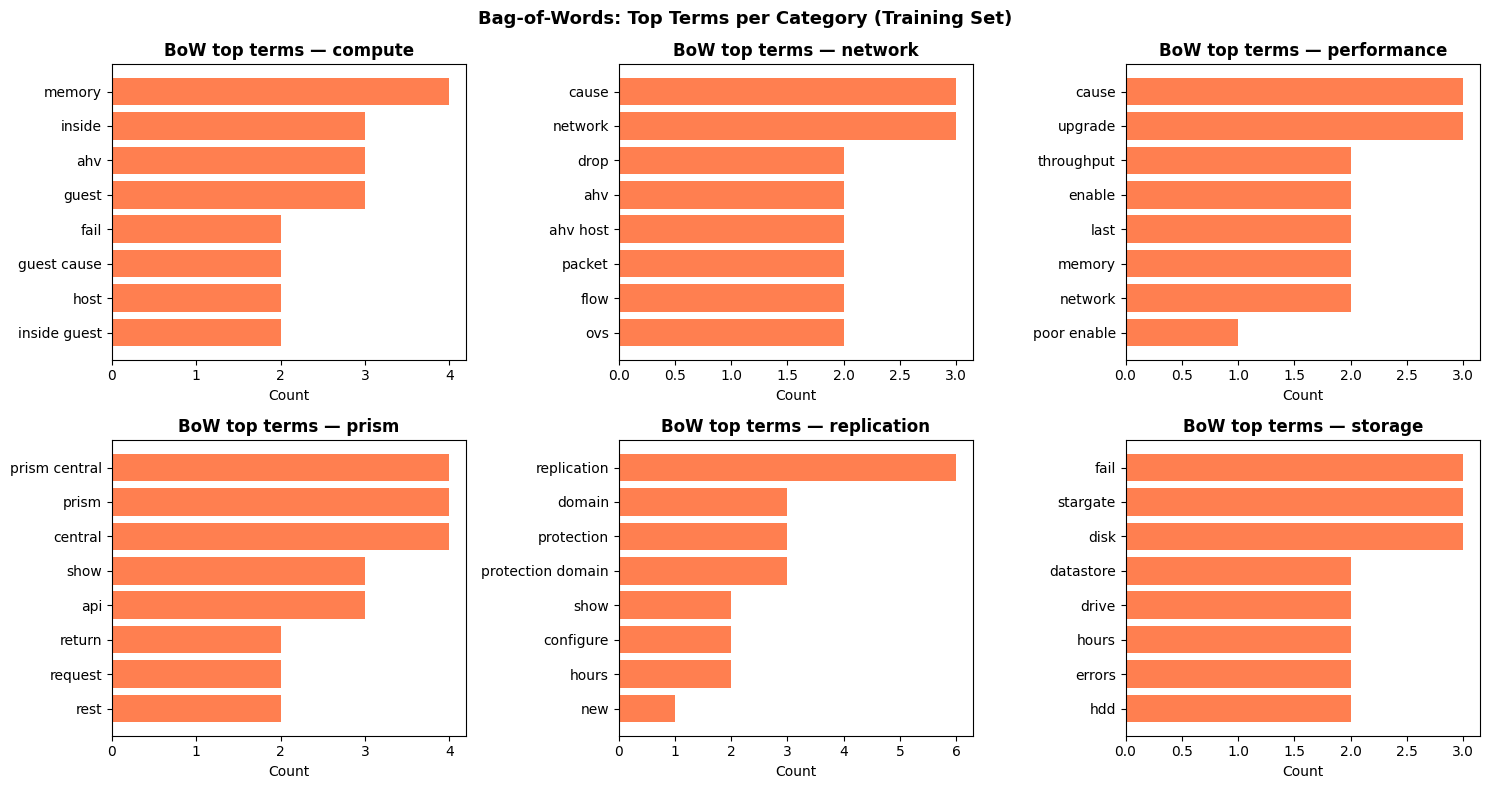

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

# Show the most discriminative BoW terms per category
feature_names = bow_vec.get_feature_names_out()
X_bow_dense = X_train_bow.toarray()

categories = sorted(np.unique(y_train))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, cat in enumerate(categories):
    mask = y_train == cat
    cat_sum = X_bow_dense[mask].sum(axis=0)
    top_idx = cat_sum.argsort()[-8:][::-1]
    axes[i].barh(feature_names[top_idx][::-1], cat_sum[top_idx][::-1], color='coral')
    axes[i].set_title(f'BoW top terms — {cat}', fontweight='bold')
    axes[i].set_xlabel('Count')

plt.suptitle('Bag-of-Words: Top Terms per Category (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bow_top_terms.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. TF-IDF (Term Frequency – Inverse Document Frequency)

TF-IDF weights each term by how *rare* it is across all documents. A term like `replication` that appears frequently in the `replication` category but rarely elsewhere gets a high TF-IDF score. A term like `upgrade` that appears in every category gets down-weighted.

$$\text{TF-IDF}(t, d) = \text{tf}(t, d) \times \log\left(\frac{N}{1 + \text{df}(t)}\right)$$

> **Instructor Note:** TF-IDF almost always outperforms raw counts for classification. The IDF factor suppresses cross-category noise. The key parameters to tune are `max_features`, `min_df` (minimum document frequency), and `ngram_range`. Bigrams (n=2) capture phrases like `live migration` and `protection domain` that are more informative than individual words.

In [ ]:
tfidf_vec = TfidfVectorizer(max_features=200, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf  = tfidf_vec.transform(X_test_text)

print(f'TF-IDF matrix shape : {X_train_tfidf.shape}')
print(f'Matrix density      : {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.3%}')

# Show IDF values — high IDF = rare = discriminative
tfidf_feature_names = tfidf_vec.get_feature_names_out()
idf_scores = tfidf_vec.idf_

top_idf_idx = idf_scores.argsort()[-15:][::-1]
print(f'\nHighest IDF (most discriminative terms):')
for idx in top_idf_idx:
    print(f'  {tfidf_feature_names[idx]:<25} IDF={idf_scores[idx]:.3f}')

TF-IDF matrix shape : (45, 200)
Matrix density      : 3.878%

Highest IDF (most discriminative terms):
  wrong                     IDF=4.135
  pressure large            IDF=4.135
  per                       IDF=4.135
  peak hours                IDF=4.135
  peak                      IDF=4.135
  path throughput           IDF=4.135
  write latency             IDF=4.135
  partner site              IDF=4.135
  partner                   IDF=4.135
  page transfer             IDF=4.135
  page login                IDF=4.135
  packet loss               IDF=4.135
  packet drop               IDF=4.135
  ovs flow                  IDF=4.135
  ovs bridge                IDF=4.135


In [ ]:
# BoW vs TF-IDF: compare scores for the same ticket
sample_idx = 0
sample_ticket = X_train_text[sample_idx]
print(f'Sample ticket: "{sample_ticket}"\n')

# BoW scores
bow_row = X_train_bow[sample_idx].toarray().flatten()
bow_top = [(bow_vec.get_feature_names_out()[i], bow_row[i]) for i in bow_row.argsort()[-6:][::-1] if bow_row[i] > 0]

# TF-IDF scores
tfidf_row = X_train_tfidf[sample_idx].toarray().flatten()
tfidf_top = [(tfidf_vec.get_feature_names_out()[i], round(tfidf_row[i], 3)) for i in tfidf_row.argsort()[-6:][::-1] if tfidf_row[i] > 0]

print(f'{"BoW top terms":<35} {"TF-IDF top terms"}')
print('-' * 65)
for (bw, bs), (tw, ts) in zip(bow_top, tfidf_top):
    print(f'  {bw:<20} cnt={bs:<8}  {tw:<20} tfidf={ts}')

Sample ticket: "rest api rate limit trigger request per minute affect automation script"

BoW top terms                       TF-IDF top terms
-----------------------------------------------------------------
  minute affect        cnt=1         minute affect        tfidf=0.32
  rate limit           cnt=1         rate limit           tfidf=0.32
  rate                 cnt=1         rate                 tfidf=0.32
  rest api             cnt=1         per minute           tfidf=0.32
  rest                 cnt=1         per                  tfidf=0.32
  per minute           cnt=1         trigger              tfidf=0.289


## 4. Word Embeddings — Word2Vec

Word embeddings represent words as dense vectors in a continuous space where semantically similar words are geometrically close. Unlike BoW/TF-IDF, embeddings capture *meaning* — `Stargate` and `disk` will be closer together than `Stargate` and `login`.

We train a small Word2Vec model on our corpus to demonstrate the concept. In production you would use a pre-trained model (GloVe, FastText, or a domain-specific embedding).

> **Instructor Note:** Word2Vec needs a large corpus (millions of sentences) to learn high-quality embeddings. On 60 tickets it's pedagogical only. In production with Nutanix log data you would either fine-tune a pre-trained model or use sentence-transformers to get ticket-level embeddings directly.

In [ ]:
from gensim.models import Word2Vec

# Tokenise cleaned text into lists of words for Word2Vec
all_sentences = [text.split() for text in X_text]

w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=50,    # embedding dimension
    window=5,          # context window
    min_count=1,       # include all terms (small corpus)
    workers=2,
    seed=42,
    epochs=50,         # more epochs to compensate for tiny corpus
)

vocab_size = len(w2v_model.wv)
print(f'Word2Vec vocabulary: {vocab_size} words')
print(f'Embedding dimension: {w2v_model.vector_size}')

# Show similar words — does the model learn domain relationships?
query_words = ['stargate', 'cerebro', 'latency', 'replication']
print()
for word in query_words:
    if word in w2v_model.wv:
        similars = w2v_model.wv.most_similar(word, topn=4)
        sim_str = ', '.join([f'{w}({s:.2f})' for w, s in similars])
        print(f'  {word:<15} → {sim_str}')

Word2Vec vocabulary: 338 words
Embedding dimension: 50

  stargate        → fail(0.91), hours(0.90), cause(0.90), degrade(0.89)
  cerebro         → become(0.76), fail(0.75), login(0.75), acropolis(0.75)
  latency         → cause(0.91), new(0.91), hours(0.90), show(0.89)
  replication     → show(0.92), cause(0.91), recovery(0.90), memory(0.90)


In [ ]:
# Document embedding: average word vectors to get a document vector
def doc_to_vec(text: str, model: Word2Vec) -> np.ndarray:
    """Average word vectors. Returns zero vector if no words in vocabulary."""
    words = text.split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_train_w2v = np.array([doc_to_vec(t, w2v_model) for t in X_train_text])
X_test_w2v  = np.array([doc_to_vec(t, w2v_model) for t in X_test_text])

print(f'Word2Vec document matrix: {X_train_w2v.shape}  (dense, not sparse)')
print(f'Compare — BoW/TF-IDF shape: {X_train_bow.shape}  (sparse)')
print()
print('Key difference: Word2Vec uses 50 dense features vs 200 sparse BoW features.')
print('Dense embeddings generalise better but need more data to learn well.')

Word2Vec document matrix: (45, 50)  (dense, not sparse)
Compare — BoW/TF-IDF shape: (45, 200)  (sparse)

Key difference: Word2Vec uses 50 dense features vs 200 sparse BoW features.
Dense embeddings generalise better but need more data to learn well.


## 5. Classifier 1 — Multinomial Naive Bayes

Naive Bayes applies Bayes' theorem assuming feature independence. For text, `MultinomialNB` works on raw counts or TF-IDF weights and is extremely fast — O(n·d) to train.

> **Instructor Note:** Despite the "naive" independence assumption (words in a document are obviously not independent), Naive Bayes is a strong baseline for text. It's been used in spam filters since the 1990s. The `alpha` parameter controls Laplace smoothing — prevents zero-probability for unseen terms.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb_bow = MultinomialNB(alpha=0.1)
nb_bow.fit(X_train_bow, y_train)
nb_bow_preds = nb_bow.predict(X_test_bow)
nb_bow_acc   = accuracy_score(y_test, nb_bow_preds)

nb_tfidf = MultinomialNB(alpha=0.1)
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_preds = nb_tfidf.predict(X_test_tfidf)
nb_tfidf_acc   = accuracy_score(y_test, nb_tfidf_preds)

print(f'Naive Bayes + BoW   accuracy: {nb_bow_acc:.2%}')
print(f'Naive Bayes + TF-IDF accuracy: {nb_tfidf_acc:.2%}')
print()
print('=== Naive Bayes + TF-IDF — per-class report ===')
print(classification_report(y_test, nb_tfidf_preds))

Naive Bayes + BoW   accuracy: 40.00%
Naive Bayes + TF-IDF accuracy: 40.00%

=== Naive Bayes + TF-IDF — per-class report ===
              precision    recall  f1-score   support

     compute       0.20      0.50      0.29         2
     network       0.00      0.00      0.00         2
 performance       0.40      0.67      0.50         3
       prism       0.67      0.67      0.67         3
 replication       1.00      0.33      0.50         3
     storage       0.00      0.00      0.00         2

    accuracy                           0.40        15
   macro avg       0.38      0.36      0.33        15
weighted avg       0.44      0.40      0.37        15



## 6. Classifier 2 — Logistic Regression

Logistic Regression with `multi_class='multinomial'` learns a weight vector for each category. It is interpretable — the weight of each TF-IDF feature tells you how much that term contributes to predicting each class.

> **Instructor Note:** Logistic Regression is the workhorse of production text classification. It trains quickly, is interpretable, and handles high-dimensional sparse input well. The `C` parameter controls regularisation — higher C = less regularisation = fits training data more closely.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=5.0, max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f'Logistic Regression + TF-IDF accuracy: {lr_acc:.2%}')
print()
print('=== per-class report ===')
print(classification_report(y_test, lr_preds))

# Show top 5 positive weights per category (model interpretability)
print('=== Top 5 TF-IDF features per category ===')
feature_names = tfidf_vec.get_feature_names_out()
for i, cat in enumerate(lr.classes_):
    top_idx = lr.coef_[i].argsort()[-5:][::-1]
    top_feats = ', '.join(feature_names[top_idx])
    print(f'  {cat:<14}: {top_feats}')

Logistic Regression + TF-IDF accuracy: 33.33%

=== per-class report ===
              precision    recall  f1-score   support

     compute       0.25      0.50      0.33         2
     network       0.00      0.00      0.00         2
 performance       0.25      0.33      0.29         3
       prism       0.67      0.67      0.67         3
 replication       1.00      0.33      0.50         3
     storage       0.00      0.00      0.00         2

    accuracy                           0.33        15
   macro avg       0.36      0.31      0.30        15
weighted avg       0.42      0.33      0.33        15

=== Top 5 TF-IDF features per category ===
  compute       : numa topology, memory, guest, unexpectedly, ahv
  network       : switch, interface, packet, flow, ovs
  performance   : enable, last, upgrade, throughput, neighbour
  prism         : central, prism central, prism, api, return
  replication   : replication, protection, domain, protection domain, configure
  storage       :

## 7. Classifier 3 — Support Vector Machine

Linear SVM finds the maximum-margin hyperplane between classes. For high-dimensional sparse text features, linear SVM is often the best performer — it handles thousands of features gracefully and is robust to outlier tickets.

> **Instructor Note:** Use `LinearSVC` (not `SVC` with `kernel='linear'`) for text classification — it uses a much faster optimisation (`liblinear`) than `SVC`'s `libsvm` and scales to large datasets. The `C` parameter is the same inverse-regularisation as in Logistic Regression.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
# Wrap in CalibratedClassifierCV to enable predict_proba (needed for confidence scores)
svm_cal = CalibratedClassifierCV(svm, cv=3)
svm_cal.fit(X_train_tfidf, y_train)
svm_preds = svm_cal.predict(X_test_tfidf)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f'SVM (LinearSVC) + TF-IDF accuracy: {svm_acc:.2%}')
print()
print('=== per-class report ===')
print(classification_report(y_test, svm_preds))

# Confidence scores for a sample prediction
sample_proba = svm_cal.predict_proba(X_test_tfidf[:1])[0]
proba_df = pd.DataFrame({'category': svm_cal.classes_, 'confidence': sample_proba}).sort_values('confidence', ascending=False)
print(f'\nConfidence for ticket: "{X_test_text[0]}"')
print(proba_df.to_string(index=False))

SVM (LinearSVC) + TF-IDF accuracy: 33.33%

=== per-class report ===
              precision    recall  f1-score   support

     compute       0.25      0.50      0.33         2
     network       0.00      0.00      0.00         2
 performance       0.25      0.33      0.29         3
       prism       0.67      0.67      0.67         3
 replication       1.00      0.33      0.50         3
     storage       0.00      0.00      0.00         2

    accuracy                           0.33        15
   macro avg       0.36      0.31      0.30        15
weighted avg       0.42      0.33      0.33        15


Confidence for ticket: "ssd cache hit ratio drop percent add new unoptimised sequential workload"
   category  confidence
    storage    0.304205
    compute    0.233248
performance    0.166414
    network    0.164370
replication    0.097845
      prism    0.033917


## 8. Word2Vec Embeddings + SVM

> **Instructor Note:** On a tiny 60-ticket corpus, Word2Vec embeddings are expected to perform poorly — they haven't seen enough data to learn meaningful domain relationships. This result demonstrates *why* data volume matters for embedding quality. On a real Nutanix support corpus with 100k tickets, embeddings would likely outperform TF-IDF.

In [ ]:
from sklearn.svm import SVC

svm_w2v = SVC(kernel='rbf', C=5.0, random_state=42)
svm_w2v.fit(X_train_w2v, y_train)
w2v_preds = svm_w2v.predict(X_test_w2v)
w2v_acc   = accuracy_score(y_test, w2v_preds)

print(f'SVM + Word2Vec avg-embedding accuracy: {w2v_acc:.2%}')
print()
print('Expected: lower than TF-IDF on this 60-ticket corpus.')
print('Word2Vec needs thousands of documents to learn useful representations.')

SVM + Word2Vec avg-embedding accuracy: 20.00%

Expected: lower than TF-IDF on this 60-ticket corpus.
Word2Vec needs thousands of documents to learn useful representations.


## 9. Model Comparison Summary

In [ ]:
from sklearn.metrics import f1_score

results = [
    ('Naive Bayes',          'BoW',     nb_bow_preds),
    ('Naive Bayes',          'TF-IDF',  nb_tfidf_preds),
    ('Logistic Regression',  'TF-IDF',  lr_preds),
    ('SVM (LinearSVC)',      'TF-IDF',  svm_preds),
    ('SVM (RBF)',            'Word2Vec', w2v_preds),
]

summary = pd.DataFrame([
    {
        'Classifier': clf,
        'Representation': rep,
        'Accuracy': f'{accuracy_score(y_test, preds):.2%}',
        'Macro F1':  f'{f1_score(y_test, preds, average="macro"):.2%}',
    }
    for clf, rep, preds in results
])
print(summary.to_string(index=False))

         Classifier Representation Accuracy Macro F1
        Naive Bayes            BoW   40.00%   31.67%
        Naive Bayes         TF-IDF   40.00%   32.54%
Logistic Regression         TF-IDF   33.33%   29.76%
    SVM (LinearSVC)         TF-IDF   33.33%   29.76%
          SVM (RBF)       Word2Vec   20.00%   17.26%


## 10. Confusion Matrix — Best Model

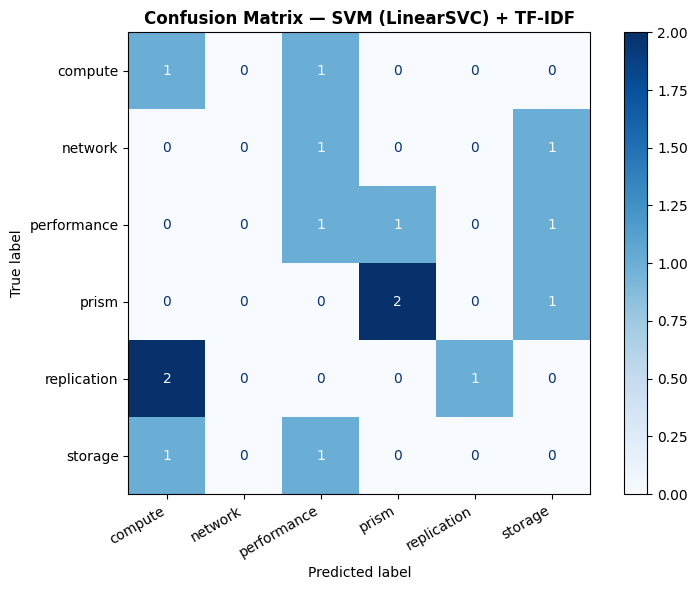

Chart saved: confusion_matrix.png


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use best model (typically LinearSVC + TF-IDF)
best_preds = svm_preds
best_label = 'SVM (LinearSVC) + TF-IDF'

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds,
    display_labels=svm_cal.classes_,
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_label}', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: confusion_matrix.png')

## 11. Lab Summary

| Representation | Strengths | Weaknesses | Best with |
|----------------|-----------|------------|-----------|
| Bag-of-Words   | Simple, fast, interpretable | Ignores term importance, large sparse matrix | Naive Bayes |
| TF-IDF         | Down-weights common terms, captures discriminative features | Still ignores word order | LR, SVM |
| Word2Vec avg   | Dense, captures semantics | Needs large corpus, loses document structure | RBF-SVM, neural nets |

| Classifier | Speed | Interpretability | Best use |
|-----------|-------|-----------------|----------|
| Naive Bayes | Fastest | Medium (word weights) | Real-time routing at high volume |
| Logistic Regression | Fast | High (feature weights) | Production with explainability need |
| LinearSVC | Fast | Medium | Highest accuracy on sparse text |

**Files produced:**
- `bow_top_terms.png` — BoW vocabulary per category
- `confusion_matrix.png` — confusion matrix for best model

> **Instructor Note:** In Lab 4.3 we take the best pipeline (TF-IDF + SVM) and build a production-ready ticket routing and log classification service with both Use Case A (tickets) and Use Case B (AOS error logs).

---
## 🎯 Challenges

### Challenge 1
The current TF-IDF uses `ngram_range=(1, 2)`. Change it to `(1, 3)` (trigrams) and compare accuracy. Are trigrams helpful for this domain? Check which trigrams are most informative using the `idf_` attribute.

### Challenge 2
Logistic Regression exposes `coef_` weights per category. For the `replication` category, print the top 10 positive weights (terms that push toward `replication`) and the top 10 negative weights (terms that push away). Do the results make domain sense?

### Challenge 3
The Word2Vec model trains on only 60 documents — far too few. Augment the corpus by generating 5 paraphrased variants of each ticket using simple word replacement (swap synonyms from a small dictionary you define). Retrain Word2Vec on the augmented corpus and check whether accuracy improves.

In [ ]:
# Challenge workspace
